# 🛍️ Online Retail Analytics — Final Advanced Notebook

**End-to-end portfolio analysis** covering data quality, transaction cleaning, sales performance, returns/cancellations, RFM scoring, K-Means customer segmentation, cohort retention, CLV, market basket rules, Pareto analysis, geography, time patterns, seasonality, and a simple revenue forecast.

> **Dataset:** Online Retail transactional data.
> **Important:** Core sales KPIs use valid positive sales transactions. Returns and cancellations are analyzed separately.

## Executive Summary

This notebook produces the final business findings after executing the full analytical pipeline. The key results are populated automatically from the data below, so this section remains reproducible rather than using placeholder statements.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ROOT = Path.cwd().resolve().parent if (Path.cwd().name == "notebooks") else Path.cwd()
RAW = ROOT / "data" / "raw" / "Online Retail.csv"
OUT = ROOT / "data" / "processed"
OUT.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")
print("Project root:", ROOT)
print("Dataset:", RAW)

Project root: /mnt/data/Online_Retail_Analytics_Final_Advanced
Dataset: /mnt/data/Online_Retail_Analytics_Final_Advanced/data/raw/Online Retail.csv


## 1. Load Data — Correct Encoding

In [2]:
df = pd.read_csv(RAW, encoding="ISO-8859-1")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Quality Audit

In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2),
    "unique": df.nunique()
})
display(quality)
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"CustomerID missing: {df.CustomerID.isna().sum():,} ({df.CustomerID.isna().mean()*100:.2f}%)")
print(f"Return rows (Quantity < 0): {(df.Quantity < 0).sum():,}")
print(f"Cancellation invoices (InvoiceNo starts with C): {df.InvoiceNo.astype(str).str.startswith('C').sum():,}")

,dtype,missing,missing_pct,unique
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,object,0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,object,0,0.00,38


Duplicate rows: 5,268
CustomerID missing: 135,080 (24.93%)
Return rows (Quantity < 0): 10,624
Cancellation invoices (InvoiceNo starts with C): 9,288


## 3. Cleaning & Feature Engineering

In [4]:
df = df.drop_duplicates().copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()
df["StockCode"] = df["StockCode"].astype(str).str.strip()
df["Description"] = df["Description"].fillna("Unknown Product").astype(str).str.strip()
df["Country"] = df["Country"].astype(str).str.strip()
df["IsCancellation"] = df["InvoiceNo"].str.startswith("C")
df["IsReturn"] = df["Quantity"] < 0
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

non_product_codes = {"POST", "DOT", "M", "BANK CHARGES", "AMAZONFEE", "CRUK", "C2"}
df["IsNonProductCode"] = df["StockCode"].str.upper().isin(non_product_codes)

# Core valid sales: positive quantity/price, non-cancelled, real product code, valid date
sales = df[
    (df["Quantity"] > 0) & (df["UnitPrice"] > 0) &
    (~df["IsCancellation"]) & (~df["IsNonProductCode"]) &
    df["InvoiceDate"].notna()
].copy()

# Returns/cancellations remain separate for audit and business analysis
returns = df[(df["Quantity"] < 0) | df["IsCancellation"]].copy()

print(f"Rows after duplicate removal: {len(df):,}")
print(f"Valid sales rows: {len(sales):,}")
print(f"Return/cancellation rows: {len(returns):,}")
print(f"Non-product rows excluded from core sales: {df['IsNonProductCode'].sum():,}")


Rows after duplicate removal: 536,641
Valid sales rows: 522,574
Return/cancellation rows: 10,587
Non-product rows excluded from core sales: 2,764


## 4. Outlier Review — Quantity & Unit Price

In [5]:
def outlier_summary(s, col):
    q1,q3=s[col].quantile([.25,.75]); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    return {"Q1":q1,"Q3":q3,"IQR":iqr,"lower":lo,"upper":hi,"outliers":int(((s[col]<lo)|(s[col]>hi)).sum())}

outliers = pd.DataFrame({k:outlier_summary(sales,k) for k in ["Quantity","UnitPrice"]}).T
display(outliers)
print("Outliers are retained for business reporting because extreme orders can be commercially meaningful; they are flagged rather than silently deleted.")

,Q1,Q3,IQR,lower,upper,outliers
Quantity,1.00,12.00,11.00,-15.50,28.50,26815.0
UnitPrice,1.25,4.13,2.88,-3.07,8.45,35775.0


Outliers are retained for business reporting because extreme orders can be commercially meaningful; they are flagged rather than silently deleted.


## 5. Executive KPIs

In [6]:
kpi = {
    "Revenue": sales.Revenue.sum(),
    "Orders": sales.InvoiceNo.nunique(),
    "Customers": sales.CustomerID.nunique(),
    "Products": sales.StockCode.nunique(),
    "Countries": sales.Country.nunique(),
    "AOV": sales.Revenue.sum()/sales.InvoiceNo.nunique(),
    "Units Sold": sales.Quantity.sum()
}
kpi_df=pd.Series(kpi,name="Value").to_frame()
display(kpi_df.style.format({"Value":"{:,.2f}"}))

,Value
Revenue,"10,259,030.24"
Orders,"19,776.00"
Customers,"4,334.00"
Products,"3,915.00"
Countries,38.00
AOV,518.76
Units Sold,"5,561,423.00"


## 6. Revenue Trend, MoM Growth & Seasonality

,YearMonth,Revenue,Orders,Customers,MoM_Growth_%,Month,MonthName
1,2011-01,"£670,439",1081,739,-13.6%,1,Jan
2,2011-02,"£507,867",1093,757,-24.2%,2,Feb
3,2011-03,"£689,842",1440,973,35.8%,3,Mar
4,2011-04,"£515,500",1236,853,-25.3%,4,Apr
5,2011-05,"£740,036",1668,1054,43.6%,5,May
6,2011-06,"£737,684",1525,990,-0.3%,6,Jun
7,2011-07,"£688,253",1452,946,-6.7%,7,Jul
8,2011-08,"£735,370",1340,933,6.8%,8,Aug
9,2011-09,"£1,028,345",1818,1259,39.8%,9,Sep
10,2011-10,"£1,103,364",2006,1361,7.3%,10,Oct


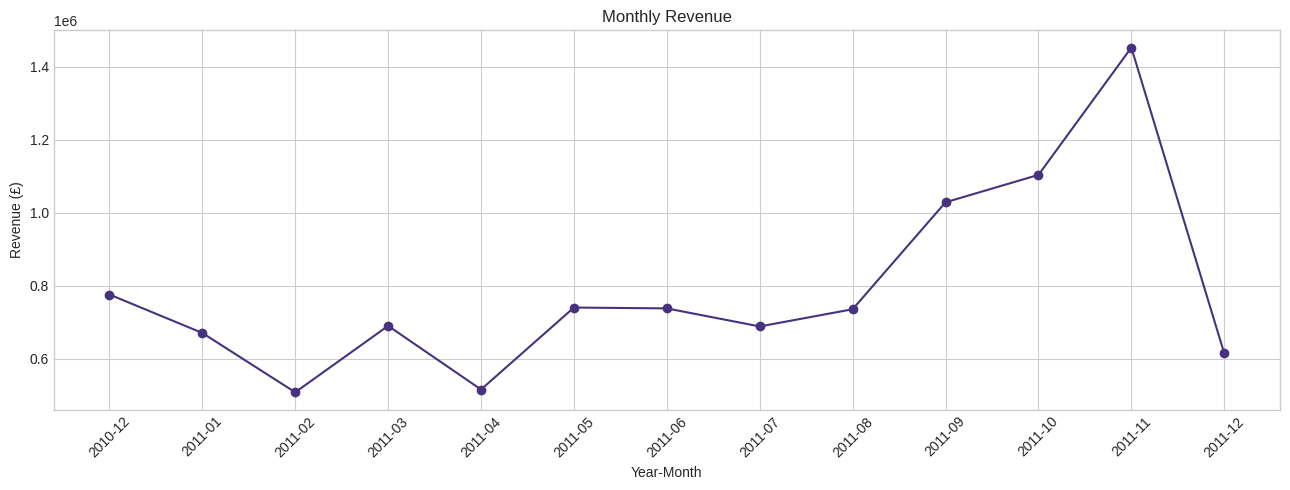

,Revenue
InvoiceDate,
November,"£1,452,116"
December,"£1,390,214"
October,"£1,103,364"
September,"£1,028,345"
May,"£740,036"
June,"£737,684"
August,"£735,370"
March,"£689,842"
July,"£688,253"


In [7]:
monthly = sales.groupby("YearMonth").agg(Revenue=("Revenue","sum"), Orders=("InvoiceNo","nunique"), Customers=("CustomerID","nunique")).reset_index()
monthly["MoM_Growth_%"] = monthly.Revenue.pct_change()*100
monthly["Month"] = pd.to_datetime(monthly.YearMonth).dt.month
monthly["MonthName"] = pd.to_datetime(monthly.YearMonth).dt.strftime("%b")
display(monthly.tail(12).style.format({"Revenue":"£{:,.0f}","MoM_Growth_%":"{:,.1f}%"}))

fig,ax=plt.subplots(figsize=(13,5)); ax.plot(monthly.YearMonth,monthly.Revenue,marker="o"); ax.set_title("Monthly Revenue"); ax.set_xlabel("Year-Month"); ax.set_ylabel("Revenue (£)"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

seasonal = sales.groupby(sales.InvoiceDate.dt.month_name()).Revenue.sum().sort_values(ascending=False)
display(seasonal.to_frame("Revenue").style.format("£{:,.0f}"))

## 7. Product Intelligence + Pareto 80/20

Top 858 products account for approximately 80.0% of revenue.


,StockCode,Description,Revenue,Quantity,Orders,Revenue_Share_%,Cumulative_%
1340,22423,REGENCY CAKESTAND 3 TIER,"£174,156.54",13851,1988,1.70%,1.70%
2665,23843,"PAPER CRAFT , LITTLE BIRDIE","£168,469.60",80995,1,1.64%,3.34%
3637,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£104,284.24",37580,2189,1.02%,4.36%
2874,47566,PARTY BUNTING,"£99,445.23",18283,1685,0.97%,5.33%
3616,85099B,JUMBO BAG RED RETROSPOT,"£94,159.81",48371,2089,0.92%,6.24%
2120,23166,MEDIUM CERAMIC TOP STORAGE JAR,"£81,700.92",78033,247,0.80%,7.04%
2026,23084,RABBIT NIGHT LIGHT,"£66,870.03",30739,994,0.65%,7.69%
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"£64,875.59",19329,1160,0.63%,8.32%
3413,84879,ASSORTED COLOUR BIRD ORNAMENT,"£58,927.62",36362,1455,0.57%,8.90%
3056,79321,CHILLI LIGHTS,"£54,096.36",10302,661,0.53%,9.43%


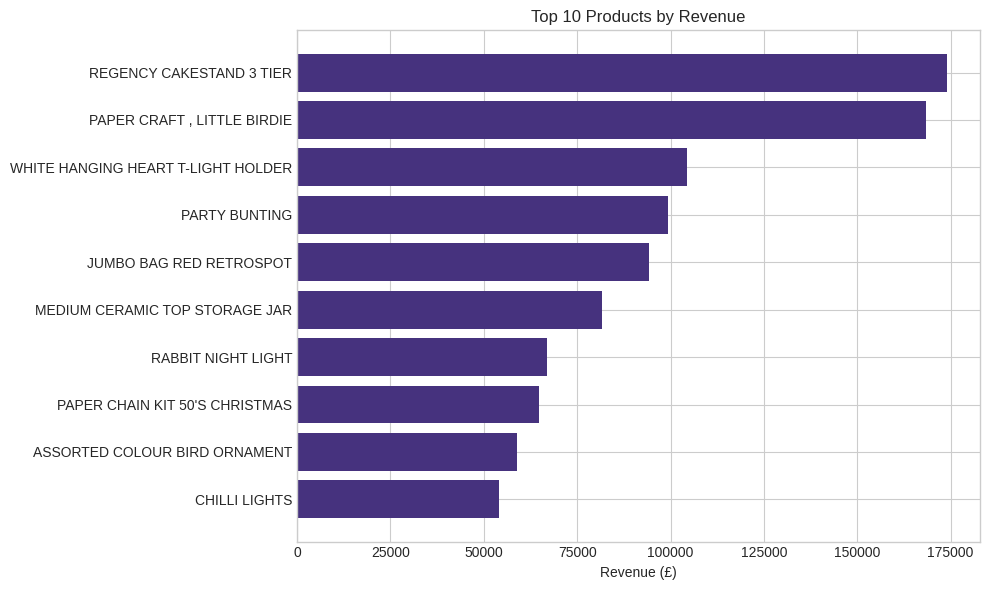

In [8]:
products=sales.groupby(["StockCode","Description"],as_index=False).agg(Revenue=("Revenue","sum"),Quantity=("Quantity","sum"),Orders=("InvoiceNo","nunique")).sort_values("Revenue",ascending=False)
products["Revenue_Share_%"] = products.Revenue/products.Revenue.sum()*100
products["Cumulative_%"] = products["Revenue_Share_%"].cumsum()
pareto_cutoff=(products["Cumulative_%"]<=80).sum()
print(f"Top {pareto_cutoff:,} products account for approximately {products.iloc[:pareto_cutoff].Revenue.sum()/products.Revenue.sum()*100:.1f}% of revenue.")
display(products.head(15).style.format({"Revenue":"£{:,.2f}","Revenue_Share_%":"{:.2f}%","Cumulative_%":"{:.2f}%"}))

top=products.head(10).sort_values("Revenue"); fig,ax=plt.subplots(figsize=(10,6)); ax.barh(top.Description.str[:45],top.Revenue); ax.set_title("Top 10 Products by Revenue"); ax.set_xlabel("Revenue (£)"); plt.tight_layout(); plt.show()

## 8. Customer RFM Scoring & Segmentation

,Customers,Revenue,Avg_Recency,Avg_Frequency
Segment,,,,
Champions,943,"£5,659,829",12.5,11.1
Loyal,507,"£898,137",37.3,5.1
At Risk,656,"£810,718",150.6,3.4
Needs Attention,1125,"£731,636",70.2,1.5
Potential Loyalists,271,"£448,624",16.7,2.2
Lost,832,"£188,285",227.0,1.0


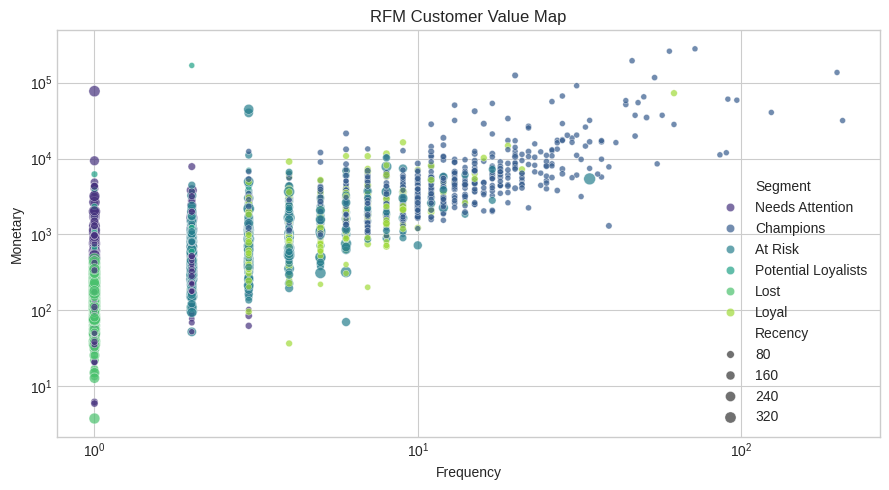

In [9]:
cust=sales.dropna(subset=["CustomerID"]).copy()
snapshot=cust.InvoiceDate.max()+pd.Timedelta(days=1)
rfm=cust.groupby("CustomerID").agg(
    Recency=("InvoiceDate",lambda x:(snapshot-x.max()).days),
    Frequency=("InvoiceNo","nunique"),
    Monetary=("Revenue","sum")
).reset_index()

# Quantile scoring; rank(method='first') prevents duplicate-value qcut failures.
rfm["R_Score"]=pd.qcut(rfm.Recency.rank(method="first"),5,labels=[5,4,3,2,1]).astype(int)
rfm["F_Score"]=pd.qcut(rfm.Frequency.rank(method="first"),5,labels=[1,2,3,4,5]).astype(int)
rfm["M_Score"]=pd.qcut(rfm.Monetary.rank(method="first"),5,labels=[1,2,3,4,5]).astype(int)
rfm["RFM_Score"]=rfm[["R_Score","F_Score","M_Score"]].sum(axis=1)

def segment(row):
    r,f,m=row.R_Score,row.F_Score,row.M_Score
    if r>=4 and f>=4 and m>=4: return "Champions"
    if r>=3 and f>=4: return "Loyal"
    if r>=4 and m>=3: return "Potential Loyalists"
    if r<=2 and f>=3: return "At Risk"
    if r<=2 and f<=2 and m<=2: return "Lost"
    return "Needs Attention"

rfm["Segment"]=rfm.apply(segment,axis=1)
segment_summary=rfm.groupby("Segment").agg(Customers=("CustomerID","count"),Revenue=("Monetary","sum"),Avg_Recency=("Recency","mean"),Avg_Frequency=("Frequency","mean")).sort_values("Revenue",ascending=False)
display(segment_summary.style.format({"Revenue":"£{:,.0f}","Avg_Recency":"{:.1f}","Avg_Frequency":"{:.1f}"}))

fig,ax=plt.subplots(figsize=(9,5)); sns.scatterplot(data=rfm,x="Frequency",y="Monetary",hue="Segment",size="Recency",alpha=.7,ax=ax); ax.set_yscale("log"); ax.set_xscale("log"); ax.set_title("RFM Customer Value Map"); plt.tight_layout(); plt.show()

## 9. K-Means Customer Segmentation

,k,Inertia,Silhouette
0,2,6476.625243,0.433041
1,3,4861.318608,0.337966
2,4,3931.764567,0.338083
3,5,3290.121330,0.317176
4,6,2849.736661,0.313096
5,7,2546.929424,0.309518
6,8,2334.252344,0.301153


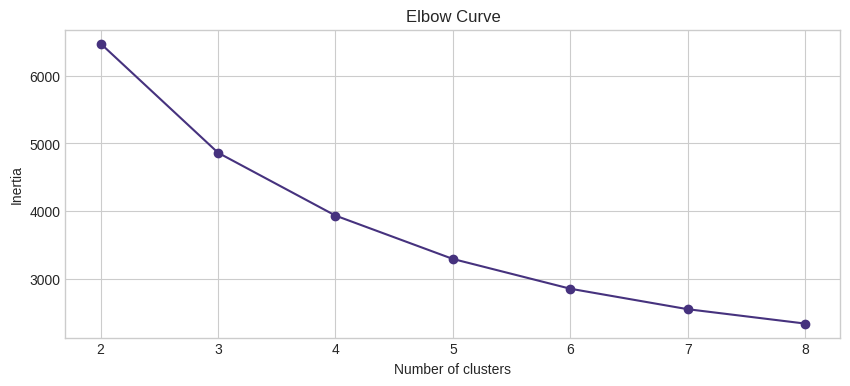

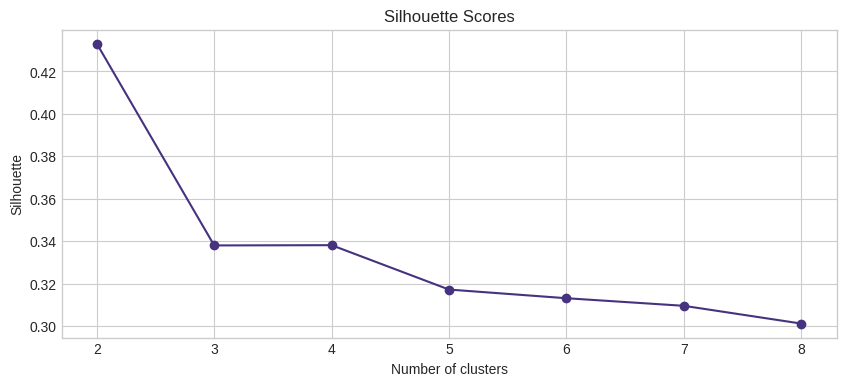

Selected k by highest silhouette: 2


,Customers,Recency,Frequency,Monetary,Revenue
KMeans_Cluster,,,,,
0,1662,25.8,8.4,"£4,464.19","£7,419,490"
1,2672,134.3,1.7,£493.17,"£1,317,738"


In [10]:
X=rfm[["Recency","Frequency","Monetary"]].copy()
X_log=np.log1p(X)
X_scaled=StandardScaler().fit_transform(X_log)
results=[]
for k in range(2,9):
    model=KMeans(n_clusters=k,random_state=42,n_init=20)
    labels=model.fit_predict(X_scaled)
    results.append((k,model.inertia_,silhouette_score(X_scaled,labels)))
kmeans_eval=pd.DataFrame(results,columns=["k","Inertia","Silhouette"]); display(kmeans_eval)

fig,ax=plt.subplots(figsize=(10,4)); ax.plot(kmeans_eval.k,kmeans_eval.Inertia,marker="o"); ax.set_title("Elbow Curve"); ax.set_xlabel("Number of clusters"); ax.set_ylabel("Inertia"); plt.show()
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(kmeans_eval.k,kmeans_eval.Silhouette,marker="o"); ax.set_title("Silhouette Scores"); ax.set_xlabel("Number of clusters"); ax.set_ylabel("Silhouette"); plt.show()

best_k=int(kmeans_eval.loc[kmeans_eval.Silhouette.idxmax(),"k"])
kmodel=KMeans(n_clusters=best_k,random_state=42,n_init=20)
rfm["KMeans_Cluster"]=kmodel.fit_predict(X_scaled)
cluster_profile=rfm.groupby("KMeans_Cluster").agg(Customers=("CustomerID","count"),Recency=("Recency","mean"),Frequency=("Frequency","mean"),Monetary=("Monetary","mean"),Revenue=("Monetary","sum")).sort_values("Revenue",ascending=False)
print("Selected k by highest silhouette:",best_k)
display(cluster_profile.style.format({"Recency":"{:.1f}","Frequency":"{:.1f}","Monetary":"£{:,.2f}","Revenue":"£{:,.0f}"}))

## 10. Returns & Cancellations Analysis

In [11]:
return_rows=df[df.Quantity<0].copy()
return_value=-return_rows.Revenue.sum()
return_revenue_pct=return_value/sales.Revenue.sum()*100
print(f"Return value: £{return_value:,.2f}")
print(f"Returns as % of gross valid-sales revenue: {return_revenue_pct:.2f}%")
print(f"Return/cancellation rows: {len(returns):,}")

ret_products=return_rows.groupby("Description",as_index=False).agg(Return_Value=("Revenue",lambda x:-x.sum()),Return_Units=("Quantity",lambda x:-x.sum())).sort_values("Return_Value",ascending=False)
ret_countries=return_rows.groupby("Country",as_index=False).agg(Return_Value=("Revenue",lambda x:-x.sum()),Return_Units=("Quantity",lambda x:-x.sum())).sort_values("Return_Value",ascending=False)
print("Top returned products:"); display(ret_products.head(10).style.format({"Return_Value":"£{:,.0f}","Return_Units":"{:,.0f}"}))
print("Top return countries:"); display(ret_countries.head(10).style.format({"Return_Value":"£{:,.0f}","Return_Units":"{:,.0f}"}))

Return value: £893,979.73
Returns as % of gross valid-sales revenue: 8.71%
Return/cancellation rows: 10,587
Top returned products:


,Description,Return_Value,Return_Units
89,AMAZON FEE,"£235,282",32
1217,"PAPER CRAFT , LITTLE BIRDIE","£168,470","80,995"
1122,Manual,"£146,784","4,066"
1052,MEDIUM CERAMIC TOP STORAGE JAR,"£77,480","74,494"
1339,POSTAGE,"£11,871",147
1434,REGENCY CAKESTAND 3 TIER,"£9,697",855
454,CRUK Commission,"£7,933",16
282,Bank Charges,"£7,341",25
1932,WHITE HANGING HEART T-LIGHT HOLDER,"£6,624","2,578"
617,FAIRY CAKE FLANNEL ASSORTED COLOUR,"£6,591","3,150"


Top return countries:


,Country,Return_Value,Return_Units
29,United Kingdom,"£812,492","468,001"
8,EIRE,"£20,147","4,786"
11,France,"£12,308","1,623"
24,Singapore,"£12,159",7
12,Germany,"£7,169","1,815"
25,Spain,"£6,803","1,127"
14,Hong Kong,"£5,575",4
22,Portugal,"£4,380",78
17,Japan,"£2,076",798
28,USA,"£1,849","1,424"


## 11. Geography — UK vs Rest of World

UK revenue share: 85.16%
Non-UK revenue share: 14.84%


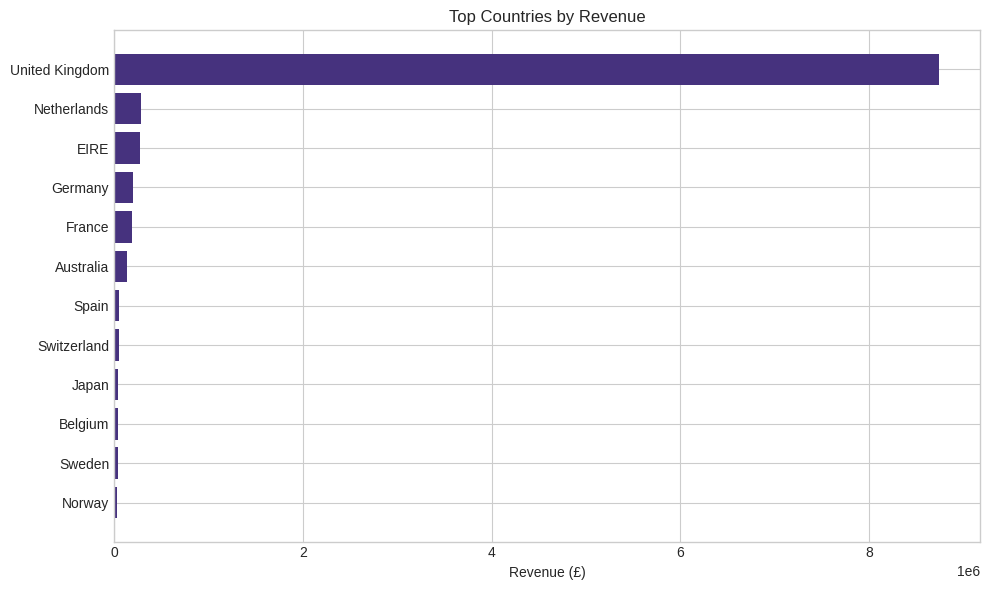

In [12]:
country=sales.groupby("Country",as_index=False).agg(Revenue=("Revenue","sum"),Orders=("InvoiceNo","nunique"),Customers=("CustomerID","nunique")).sort_values("Revenue",ascending=False)
uk_rev=country.loc[country.Country.eq("United Kingdom"),"Revenue"].sum()
nonuk_rev=country.loc[~country.Country.eq("United Kingdom"),"Revenue"].sum()
print(f"UK revenue share: {uk_rev/sales.Revenue.sum()*100:.2f}%")
print(f"Non-UK revenue share: {nonuk_rev/sales.Revenue.sum()*100:.2f}%")

top=country.head(12).sort_values("Revenue"); fig,ax=plt.subplots(figsize=(10,6)); ax.barh(top.Country,top.Revenue); ax.set_title("Top Countries by Revenue"); ax.set_xlabel("Revenue (£)"); plt.tight_layout(); plt.show()

## 12. Day × Hour Heatmap

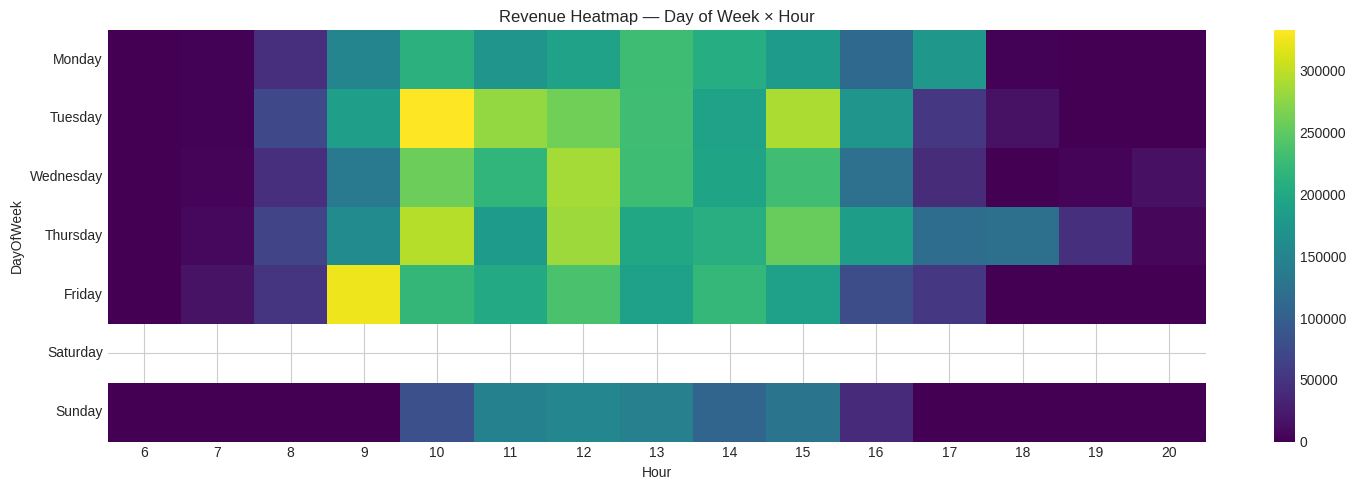

,Revenue,Orders
DayOfWeek,,
Monday,"£1,683,050","3,077"
Tuesday,"£2,085,115","3,509"
Wednesday,"£1,782,499","3,668"
Thursday,"£2,131,756","4,209"
Friday,"£1,778,299","3,110"
Saturday,£nan,nan
Sunday,"£798,312","2,203"


In [13]:
day_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heat=sales.pivot_table(index="DayOfWeek",columns="Hour",values="Revenue",aggfunc="sum",fill_value=0).reindex(day_order)
fig,ax=plt.subplots(figsize=(15,5)); sns.heatmap(heat, cmap="viridis", ax=ax); ax.set_title("Revenue Heatmap — Day of Week × Hour"); plt.tight_layout(); plt.show()

day_summary=sales.groupby("DayOfWeek").agg(Revenue=("Revenue","sum"),Orders=("InvoiceNo","nunique")).reindex(day_order)
display(day_summary.style.format({"Revenue":"£{:,.0f}","Orders":"{:,.0f}"}))

## 13. Cohort / Retention Analysis

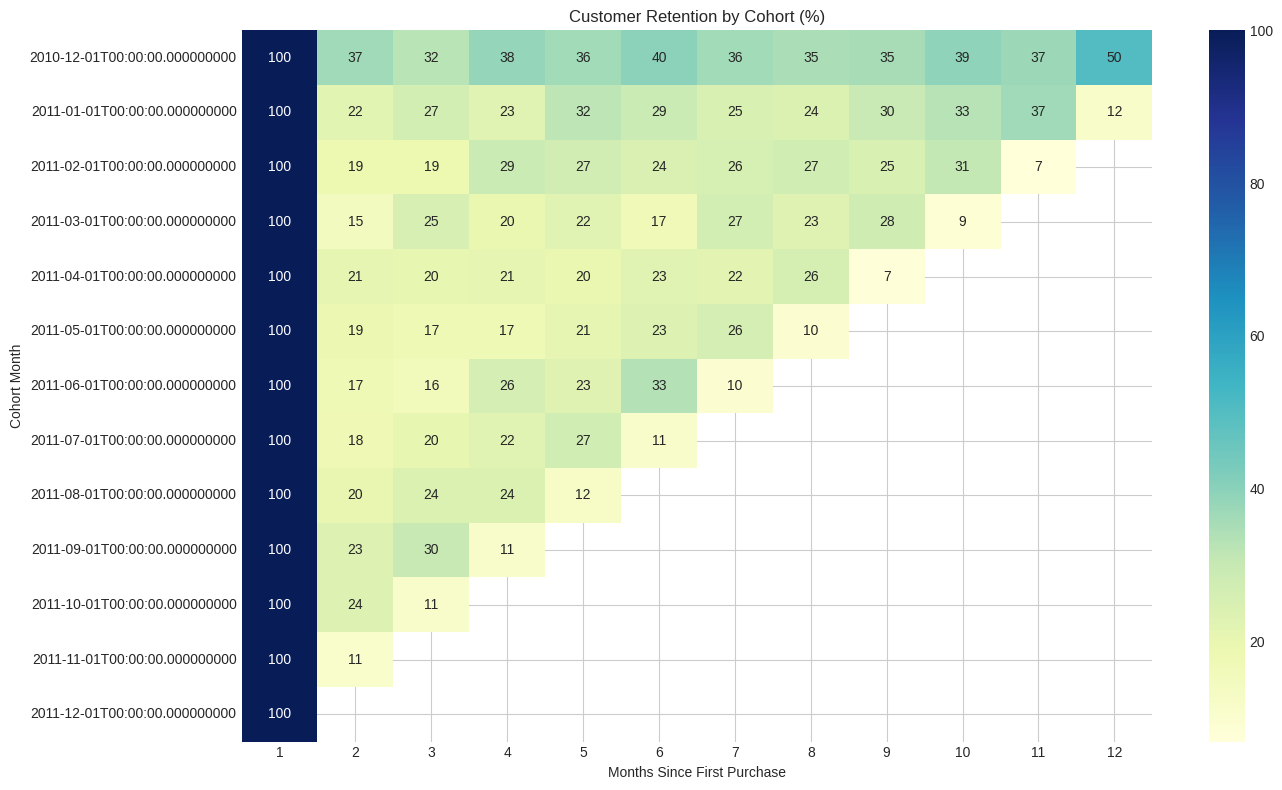

Each cell is the percentage of a cohort that purchased again in that month index.


In [14]:
co=sales.dropna(subset=["CustomerID"]).copy()
co["InvoiceMonth"]=co.InvoiceDate.dt.to_period("M").dt.to_timestamp()
first=co.groupby("CustomerID")["InvoiceMonth"].min().rename("CohortMonth")
co=co.join(first,on="CustomerID")
co["CohortIndex"]=((co.InvoiceMonth.dt.year-co.CohortMonth.dt.year)*12+(co.InvoiceMonth.dt.month-co.CohortMonth.dt.month)+1)
cohort_counts=co.groupby(["CohortMonth","CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot=cohort_counts.pivot(index="CohortMonth",columns="CohortIndex",values="CustomerID")
retention=cohort_pivot.divide(cohort_pivot.iloc[:,0],axis=0)*100
fig,ax=plt.subplots(figsize=(14,8)); sns.heatmap(retention.iloc[:,:12],annot=True,fmt=".0f",cmap="YlGnBu",ax=ax); ax.set_title("Customer Retention by Cohort (%)"); ax.set_xlabel("Months Since First Purchase"); ax.set_ylabel("Cohort Month"); plt.tight_layout(); plt.show()
print("Each cell is the percentage of a cohort that purchased again in that month index.")

## 14. Simple CLV Estimate

In [15]:
# Historical descriptive CLV proxy: average customer value × purchase frequency proxy.
# This is intentionally simple and should not be confused with a probabilistic BG/NBD + Gamma-Gamma CLV model.
rfm["Historical_CLV_Proxy"]=rfm.Monetary
clv_summary=rfm.groupby("Segment").agg(Customers=("CustomerID","count"),Avg_CLV=("Historical_CLV_Proxy","mean"),Total_Value=("Historical_CLV_Proxy","sum")).sort_values("Avg_CLV",ascending=False)
display(clv_summary.style.format({"Avg_CLV":"£{:,.2f}","Total_Value":"£{:,.0f}"}))
print("Interpretation: this CLV section is a historical customer-value proxy, not a forward-looking probabilistic CLV forecast.")

,Customers,Avg_CLV,Total_Value
Segment,,,
Champions,943,"£6,001.94","£5,659,829"
Loyal,507,"£1,771.47","£898,137"
Potential Loyalists,271,"£1,655.44","£448,624"
At Risk,656,"£1,235.85","£810,718"
Needs Attention,1125,£650.34,"£731,636"
Lost,832,£226.30,"£188,285"


Interpretation: this CLV section is a historical customer-value proxy, not a forward-looking probabilistic CLV forecast.


## 15. Market Basket Analysis — Association Rules

In [16]:
# Lightweight pairwise association rules without an external package.
# To keep runtime practical, use each invoice once per product and focus on the most frequently purchased products.
mb=sales[sales.InvoiceNo.notna()].copy()
product_counts=mb.groupby("StockCode")["InvoiceNo"].nunique().sort_values(ascending=False)
top_codes=product_counts.head(150).index
mb=mb[mb.StockCode.isin(top_codes)]
baskets=mb.groupby("InvoiceNo")["StockCode"].apply(lambda x: set(x)).tolist()
baskets=[b for b in baskets if len(b)>=2]
N=len(baskets)
from collections import Counter
item_count=Counter(); pair_count=Counter()
for b in baskets:
    for a in b: item_count[a]+=1
    items=sorted(b)
    for i,a in enumerate(items):
        for b2 in items[i+1:]: pair_count[(a,b2)]+=1

rules=[]
min_support=.002
for (a,b),cnt in pair_count.items():
    support=cnt/N
    if support < min_support: continue
    conf_ab=cnt/item_count[a]
    conf_ba=cnt/item_count[b]
    lift_ab=conf_ab/(item_count[b]/N)
    lift_ba=conf_ba/(item_count[a]/N)
    rules.extend([(a,b,support,conf_ab,lift_ab),(b,a,support,conf_ba,lift_ba)])
rules=pd.DataFrame(rules,columns=["Antecedent","Consequent","Support","Confidence","Lift"]).sort_values(["Lift","Confidence"],ascending=False)
name_map=sales.drop_duplicates("StockCode").set_index("StockCode")["Description"].to_dict()
rules["Antecedent_Product"]=rules.Antecedent.map(name_map)
rules["Consequent_Product"]=rules.Consequent.map(name_map)
display(rules.head(20).style.format({"Support":"{:.2%}","Confidence":"{:.2%}","Lift":"{:.2f}"}))

,Antecedent,Consequent,Support,Confidence,Lift,Antecedent_Product,Consequent_Product
451,22867,22866,2.01%,52.29%,13.70,HAND WARMER BIRD DESIGN,HAND WARMER SCOTTY DOG DESIGN
450,22866,22867,2.01%,52.68%,13.70,HAND WARMER SCOTTY DOG DESIGN,HAND WARMER BIRD DESIGN
368,22865,22866,2.36%,51.94%,13.60,HAND WARMER OWL DESIGN,HAND WARMER SCOTTY DOG DESIGN
369,22866,22865,2.36%,61.92%,13.60,HAND WARMER SCOTTY DOG DESIGN,HAND WARMER OWL DESIGN
1337,22867,22865,2.19%,57.06%,12.54,HAND WARMER BIRD DESIGN,HAND WARMER OWL DESIGN
1336,22865,22867,2.19%,48.22%,12.54,HAND WARMER OWL DESIGN,HAND WARMER BIRD DESIGN
20311,23322,23321,2.10%,53.60%,12.21,LARGE WHITE HEART OF WICKER,SMALL WHITE HEART OF WICKER
20310,23321,23322,2.10%,47.91%,12.21,SMALL WHITE HEART OF WICKER,LARGE WHITE HEART OF WICKER
772,21914,21915,2.23%,53.38%,11.80,BLUE HARMONICA IN BOX,RED HARMONICA IN BOX
773,21915,21914,2.23%,49.30%,11.80,RED HARMONICA IN BOX,BLUE HARMONICA IN BOX


## 16. Simple Revenue Forecast

,Forecast_Revenue
2012-01-01 00:00:00,"£1,022,160"
2012-02-01 00:00:00,"£1,054,007"
2012-03-01 00:00:00,"£1,085,854"


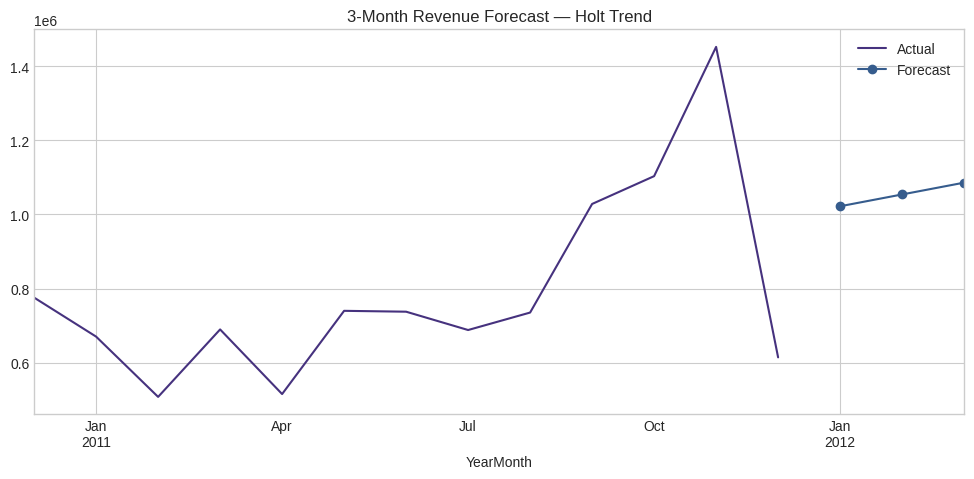

In [17]:
forecast_df=monthly.set_index(pd.to_datetime(monthly.YearMonth+"-01"))["Revenue"].asfreq("MS")
if len(forecast_df)>=6:
    model=ExponentialSmoothing(forecast_df,trend="add",seasonal=None).fit(optimized=True)
    fc=model.forecast(3)
    display(fc.to_frame("Forecast_Revenue").style.format("£{:,.0f}"))
    fig,ax=plt.subplots(figsize=(12,5)); forecast_df.plot(ax=ax,label="Actual"); fc.plot(ax=ax,label="Forecast",marker="o"); ax.legend(); ax.set_title("3-Month Revenue Forecast — Holt Trend"); plt.show()
else:
    print("Not enough monthly observations for a reliable forecast.")

## 17. Final Data-Driven Insights

In [18]:
top_product=products.iloc[0]
top_country=country.iloc[0]
top_customer=rfm.sort_values("Monetary",ascending=False).iloc[0]
top10_customer_share=rfm.nlargest(max(1,int(len(rfm)*0.10)),"Monetary").Monetary.sum()/rfm.Monetary.sum()*100
champ=segment_summary.loc["Champions"] if "Champions" in segment_summary.index else None

insights=[
    f"**Revenue:** £{sales.Revenue.sum():,.0f} across {sales.InvoiceNo.nunique():,} valid orders, with an average order value of £{sales.Revenue.sum()/sales.InvoiceNo.nunique():,.2f}.",
    f"**Product concentration:** the top {pareto_cutoff:,} products generate approximately {products.iloc[:pareto_cutoff].Revenue.sum()/products.Revenue.sum()*100:.1f}% of revenue.",
    f"**Customer concentration:** the highest-value 10% of identifiable customers contribute {top10_customer_share:.1f}% of customer revenue.",
    f"**Geography:** the United Kingdom contributes {uk_rev/sales.Revenue.sum()*100:.1f}% of valid-sales revenue; the rest of the world contributes {nonuk_rev/sales.Revenue.sum()*100:.1f}%.",
    f"**Returns:** negative-quantity transactions represent £{return_value:,.0f} of return value, equivalent to {return_revenue_pct:.2f}% of valid-sales revenue.",
    f"**Top product:** {top_product.Description} leads product revenue at £{top_product.Revenue:,.0f}.",
    f"**Top country:** {top_country.Country} leads country revenue at £{top_country.Revenue:,.0f}."
]
display(Markdown("\n\n".join("- "+x for x in insights)))

- **Revenue:** £10,259,030 across 19,776 valid orders, with an average order value of £518.76.

- **Product concentration:** the top 858 products generate approximately 80.0% of revenue.

- **Customer concentration:** the highest-value 10% of identifiable customers contribute 61.4% of customer revenue.

- **Geography:** the United Kingdom contributes 85.2% of valid-sales revenue; the rest of the world contributes 14.8%.

- **Returns:** negative-quantity transactions represent £893,980 of return value, equivalent to 8.71% of valid-sales revenue.

- **Top product:** REGENCY CAKESTAND 3 TIER leads product revenue at £174,157.

- **Top country:** United Kingdom leads country revenue at £8,736,255.

## 18. Reproducibility & Deliverables

The notebook uses relative project paths (`../data/raw/...`) and `encoding="ISO-8859-1"`. It separates valid sales from returns/cancellations, documents missing `CustomerID`, and keeps outliers flagged rather than silently deleting potentially meaningful transactions.

**Dashboard note:** the interactive Streamlit dashboard is a separate deliverable in `dashboard/app.py`; this notebook is the analytical source of truth and does not pretend that the dashboard itself is inside the notebook.